In [55]:
import pandas as pd
import seaborn as sns
from scipy import stats
import numpy as np

# Loading data
df = pd.read_csv('cwurData.csv')

In [56]:
# Get statistical summary of numerical columns.
df.describe()

,world_rank,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2000.000000,2200.000000,2200.000000,2200.000000
mean,459.590909,40.278182,275.100455,357.116818,178.888182,459.908636,459.797727,413.417273,496.699500,433.346364,47.798395,2014.318182
std,304.320363,51.740870,121.935100,186.779252,64.050885,303.760352,303.331822,264.366549,286.919755,273.996525,7.760806,0.762130
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,43.360000,2012.000000
25%,175.750000,6.000000,175.750000,175.750000,175.750000,175.750000,175.750000,161.000000,250.500000,170.750000,44.460000,2014.000000
50%,450.500000,21.000000,355.000000,450.500000,210.000000,450.500000,450.500000,406.000000,496.000000,426.000000,45.100000,2014.000000
75%,725.250000,49.000000,367.000000,478.000000,218.000000,725.000000,725.250000,645.000000,741.000000,714.250000,47.545000,2015.000000
max,1000.000000,229.000000,367.000000,567.000000,218.000000,1000.000000,991.000000,812.000000,1000.000000,871.000000,100.000000,2015.000000


In [57]:
# -- Processing of passes --

# Clear data from <Nan>.
df_clean = df.dropna()

# Check for <Nan> before and after cleaning.
print(df.isna().sum())
print()
print(df_clean.isnull().sum())

world_rank                0
institution               0
country                   0
national_rank             0
quality_of_education      0
alumni_employment         0
quality_of_faculty        0
publications              0
influence                 0
citations                 0
broad_impact            200
patents                   0
score                     0
year                      0
dtype: int64

world_rank              0
institution             0
country                 0
national_rank           0
quality_of_education    0
alumni_employment       0
quality_of_faculty      0
publications            0
influence               0
citations               0
broad_impact            0
patents                 0
score                   0
year                    0
dtype: int64


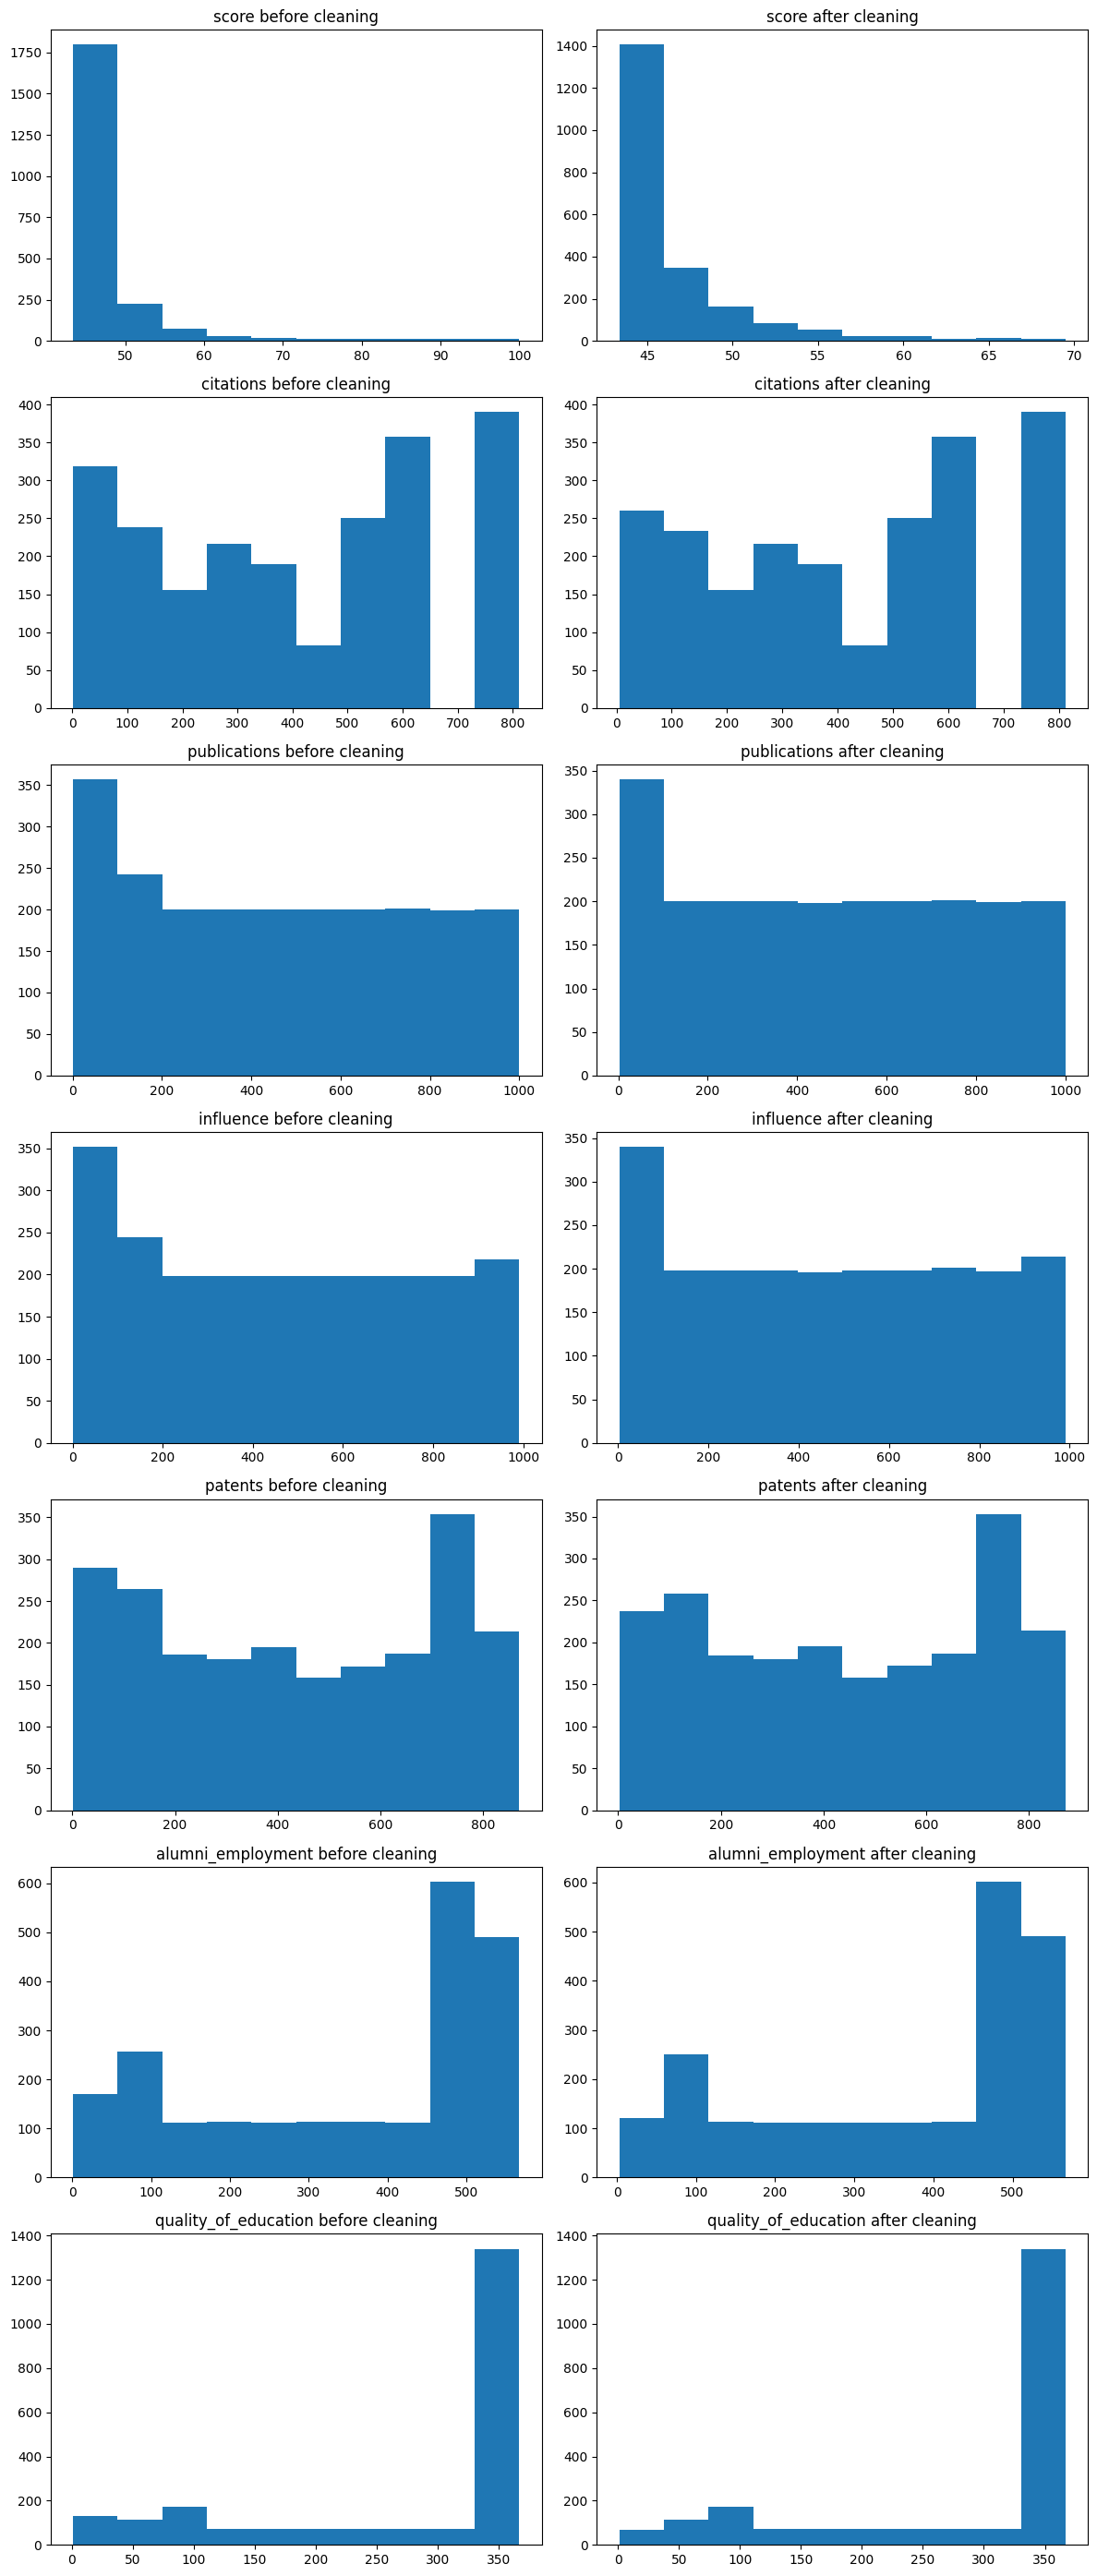

In [81]:
# -- Finding and Removing Outliers --

# Removing outliers using the <Z-score> method.
numeric_cols = ['score', 'citations', 'publications', 'influence', 'patents', 'alumni_employment', 'quality_of_education']
z_scores = stats.zscore(df[numeric_cols])
abs_z = np.abs(z_scores)
df_clean = df[(abs_z < 3).all(axis=1)]

# Output of graphs before and after cleaning.
n = len(numeric_cols)
plt.figure(figsize=(12, 4 * n))  # Adjust the height depending on the number of graphs.

for i, col in enumerate(numeric_cols):
    # before cleaning
    plt.subplot(n, 2, 2*i + 1)
    plt.hist(df[col].dropna(), bins=10)
    plt.title(f'{col} before cleaning')

    # after cleaning
    plt.subplot(n, 2, 2*i + 2)
    plt.hist(df_clean[col].dropna(), bins=10)
    plt.title(f'{col} after cleaning')

plt.tight_layout()
plt.show()

In [82]:
# -- Correlation analysis --
# Cols: score, citations, publications, influence, patents, alumni_employment, quality_of_education
corr = df_clean[numeric_cols].corr()
corr

,score,citations,publications,influence,patents,alumni_employment,quality_of_education
score,1.000000,-0.623190,-0.637715,-0.633438,-0.541073,-0.532516,-0.614024
citations,-0.623190,1.000000,0.818433,0.834562,0.571639,0.523875,0.596427
publications,-0.637715,0.818433,1.000000,0.866699,0.650214,0.539426,0.592389
influence,-0.633438,0.834562,0.866699,1.000000,0.586231,0.490496,0.614740
patents,-0.541073,0.571639,0.650214,0.586231,1.000000,0.492280,0.485260
alumni_employment,-0.532516,0.523875,0.539426,0.490496,0.492280,1.000000,0.560517
quality_of_education,-0.614024,0.596427,0.592389,0.614740,0.485260,0.560517,1.000000


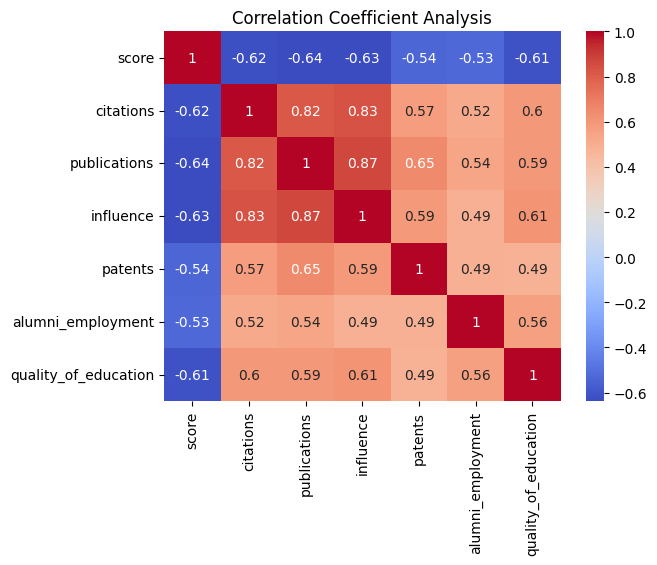

In [83]:
# Draw a correlation graph.
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Coefficient Analysis')
plt.show()

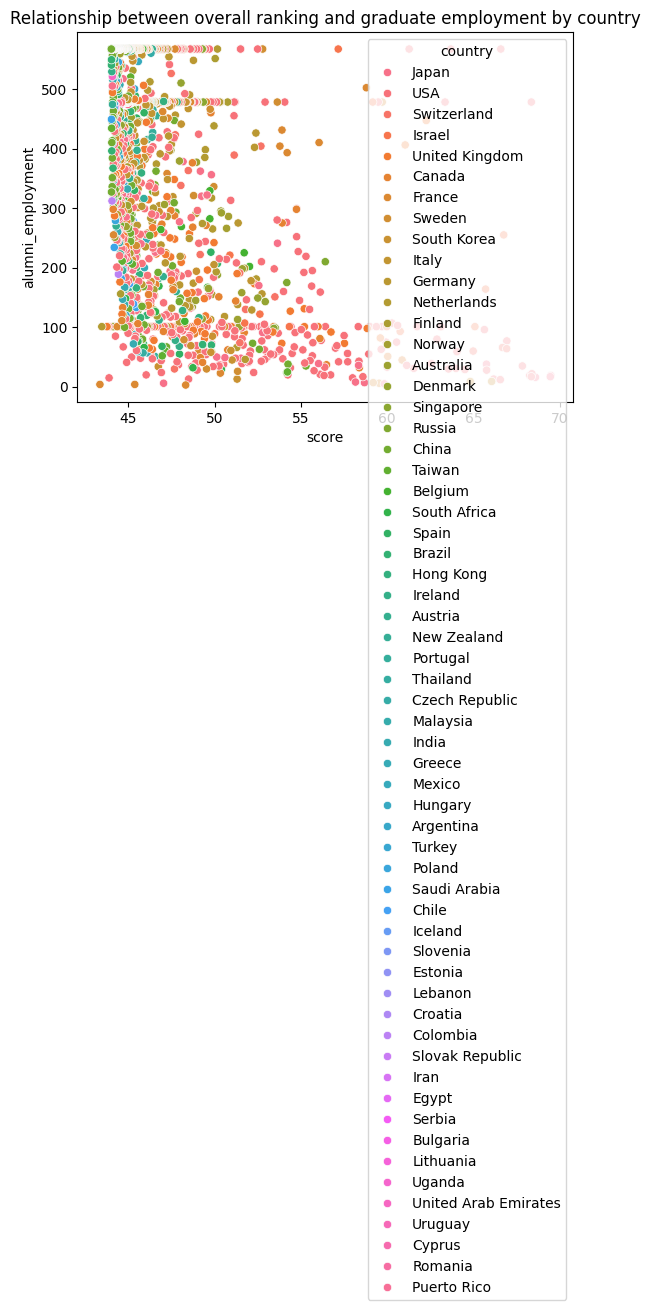

In [84]:
sns.scatterplot(x='score', y='alumni_employment', hue='country', data=df_clean)
plt.title('Relationship between overall ranking and graduate employment by country')
plt.show()

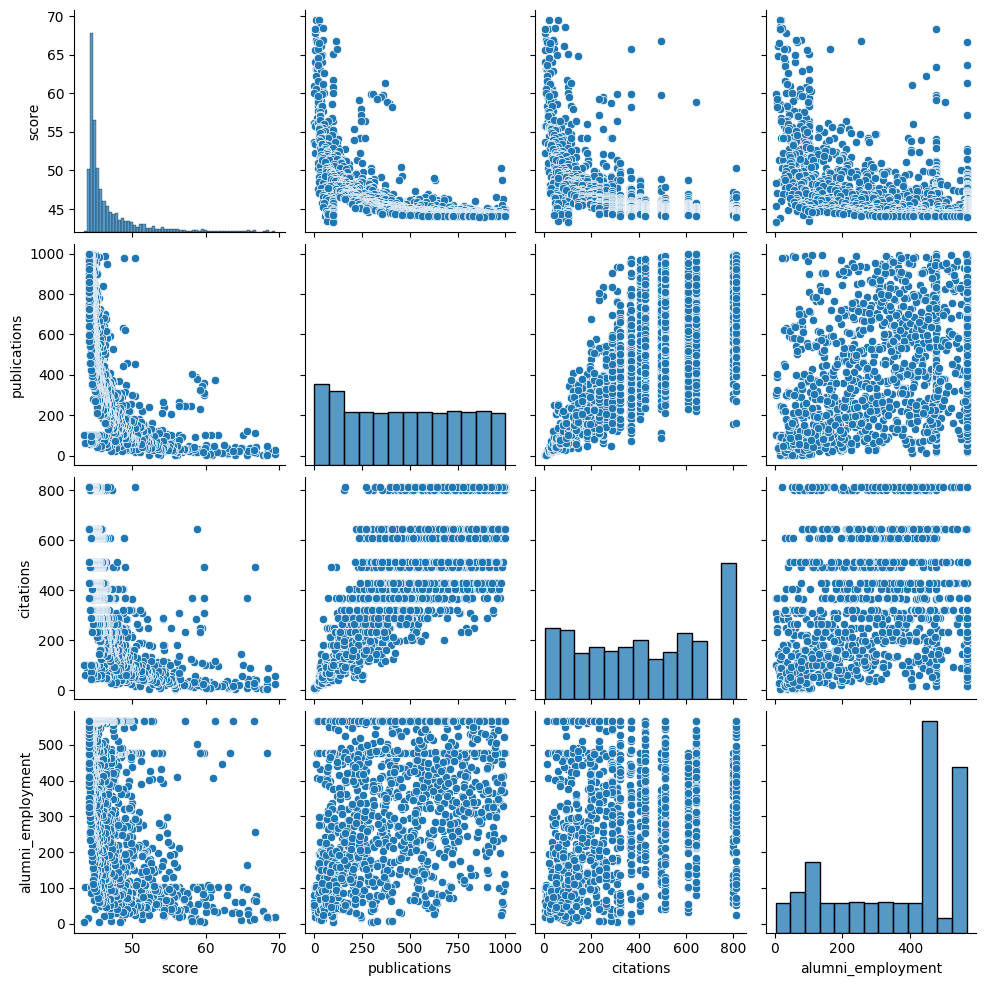

In [85]:
# Analysis of the relationships between key academic metrics.
sns.pairplot(df_clean[['score','publications','citations','alumni_employment']])
plt.show()